In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("anirudhcv/labeled-optical-coherence-tomography-oct")

print("Path to dataset files:", path)

100%|██████████| 6.70G/6.70G [01:17<00:00, 92.3MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2


In [9]:
for root, dirs, files in os.walk(path):
    print(root, "->", len(files), "files")

/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2 -> 0 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test -> 0 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val -> 0 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val/DRUSEN -> 1773 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val/CNV -> 7491 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val/NORMAL -> 10278 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-coherence-tomography-oct/versions/2/Dataset - train+val+test/val/DME -> 2319 files
/root/.cache/kagglehub/datasets/anirudhcv/labeled-optical-co

In [8]:
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from tensorflow.keras.utils import image_dataset_from_directory
import os

Data Preparation

In [10]:
train_data_dir = os.path.join(path, "Dataset - train+val+test/train")

training_set = image_dataset_from_directory(
    train_data_dir,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False,

)

Found 76515 files belonging to 4 classes.


In [11]:
val_data_dir = os.path.join(path, "Dataset - train+val+test/train")

validation_set = image_dataset_from_directory(
    val_data_dir,
    labels="inferred",
    label_mode="int",
    class_names=None,
    color_mode="rgb",
    batch_size=32,
    image_size=(224, 224),
    shuffle=True,
    seed=None,
    validation_split=None,
    subset=None,
    interpolation="bilinear",
    follow_links=False,
    crop_to_aspect_ratio=False
)

Found 76515 files belonging to 4 classes.


In [12]:
print(training_set)

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int32, name=None))>


In [13]:
INPUT_SHAPE = (224, 224, 3)

In [14]:
mobNet = tf.keras.applications.MobileNetV3Large(
    input_shape=INPUT_SHAPE, # Define input shape for the base model
    alpha=1.0,
    minimalistic=False,
    include_top=False, # Remove the pre-trained classification head
    weights="imagenet",
    pooling=None, # We'll add global pooling explicitly after this layer
    include_preprocessing=True,
    name="MobileNetV3Large",
)

12683000/12683000 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [15]:
model = tf.keras.Sequential()


In [16]:
model.add(mobNet)
model.add(tf.keras.layers.GlobalAveragePooling2D()) # Add a pooling layer to flatten features

In [17]:
model.add(tf.keras.layers.Dense(units = 4, activation = 'softmax'))

In [18]:
metrics_list = ["accuracy", tf.keras.metrics.F1Score()]

In [19]:
import tensorflow as tf

class CategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, name="categorical_focal_loss"):
        super().__init__(name=name)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1. - p_t, self.gamma)
        ce = -y_true * tf.math.log(y_pred)
        loss = focal_weight * ce
        return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

# This line creates the variable that your compile cell is looking for
focal_loss_fn = CategoricalFocalLoss(gamma=2.0)
print("Focal Loss function defined successfully!")

Focal Loss function defined successfully!


In [20]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss=focal_loss_fn,
    metrics=metrics_list
)

In [21]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ MobileNetV3Large (Functional)   │ (None, 7, 7, 960)      │     2,996,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 960)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 4)              │         3,844 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,000,196 (11.44 MB)

 Trainable params: 2,975,796 (11.35 MB)

 Non-trainable params: 24,400 (95.31 KB)

In [22]:
num_classes = 4 # The model has 4 output classes

def one_hot_encode_labels(image, label):
    return image, tf.one_hot(label, num_classes)

training_set_one_hot = training_set.map(one_hot_encode_labels)
validation_set_one_hot = validation_set.map(one_hot_encode_labels)

training_history = model.fit(
    x=training_set_one_hot,
    validation_data=validation_set_one_hot,
    epochs=15
)

Epoch 1/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 570s 210ms/step - accuracy: 0.9356 - f1_score: 0.8880 - loss: 0.0735 - val_accuracy: 0.9460 - val_f1_score: 0.9115 - val_loss: 0.0512
Epoch 2/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 409s 164ms/step - accuracy: 0.9709 - f1_score: 0.9488 - loss: 0.0272 - val_accuracy: 0.9733 - val_f1_score: 0.9543 - val_loss: 0.0233
Epoch 3/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 384s 160ms/step - accuracy: 0.9812 - f1_score: 0.9668 - loss: 0.0157 - val_accuracy: 0.9826 - val_f1_score: 0.9713 - val_loss: 0.0152
Epoch 4/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 369s 154ms/step - accuracy: 0.9873 - f1_score: 0.9777 - loss: 0.0106 - val_accuracy: 0.9889 - val_f1_score: 0.9805 - val_loss: 0.0095
Epoch 5/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 417s 174ms/step - accuracy: 0.9902 - f1_score: 0.9827 - loss: 0.0080 - val_accuracy: 0.9875 - val_f1_score: 0.9794 - val_loss: 0.0101
Epoch 6/15
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 367s 154ms/step - accuracy: 0.9914 - f1_score: 0.9849 - loss: 0.0070 - val_acc

In [24]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [25]:
#Save the Model directly to Drive
model.save("/content/drive/MyDrive/Eye_Disease_Project/trained_eye_disease_model.keras")
print("Model saved to Drive successfully!")

Model saved to Drive successfully!


In [22]:
history = load_history

{'accuracy': [0.9359210729598999,
  0.9713128209114075,
  0.9821080565452576,
  0.9873619675636292,
  0.9901587963104248,
  0.991936206817627,
  0.9924589991569519,
  0.9933346509933472,
  0.9935960173606873,
  0.9937136769294739,
  0.994811475276947,
  0.9945892691612244,
  0.9949813485145569,
  0.9948768019676208,
  0.9951643347740173],
 'f1_score': [array([0.94542205, 0.8883306 , 0.7525205 , 0.96926796], dtype=float32),
  array([0.9753598 , 0.95849377, 0.8783484 , 0.98694134], dtype=float32),
  array([0.98518956, 0.97619486, 0.92141753, 0.99157673], dtype=float32),
  array([0.9891677 , 0.98427176, 0.943146  , 0.9943346 ], dtype=float32),
  array([0.9917589 , 0.98865736, 0.9551204 , 0.9953734 ], dtype=float32),
  array([0.99284744, 0.9897085 , 0.9640206 , 0.9965822 ], dtype=float32),
  array([0.99343634, 0.9907013 , 0.9665056 , 0.99662316], dtype=float32),
  array([0.9943731 , 0.9916183 , 0.9704627 , 0.99691457], dtype=float32),
  array([0.99446833, 0.99254787, 0.97102845, 0.99709475

In [26]:
#saving history
import pickle

with open('/content/drive/MyDrive/Eye_Disease_Project/training_history.pkl', 'wb') as f:
    pickle.dump(training_history.history, f)

print("History saved to Drive successfully!")

History saved to Drive successfully!


In [27]:
#Reload history
import pickle

# Path to the file in your Drive folder
file_path = '/content/drive/MyDrive/Eye_Disease_Project/training_history.pkl'

# Open in read-binary ("rb") mode
with open(file_path, "rb") as f:
    load_history = pickle.load(f)

# Step 3: Verify it loaded correctly
print("History loaded successfully!")
#print("Available keys:", load_history.keys())

History loaded successfully!


In [28]:
load_history.keys()

dict_keys(['accuracy', 'f1_score', 'loss', 'val_accuracy', 'val_f1_score', 'val_loss'])

In [30]:
import tensorflow as tf

@tf.keras.utils.register_keras_serializable()
class CategoricalFocalLoss(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, name="categorical_focal_loss", **kwargs):
        super().__init__(name=name, **kwargs)
        self.gamma = gamma

    def call(self, y_true, y_pred):
        y_pred = tf.clip_by_value(y_pred, tf.keras.backend.epsilon(), 1. - tf.keras.backend.epsilon())
        p_t = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
        focal_weight = tf.pow(1. - p_t, self.gamma)
        ce = -y_true * tf.math.log(y_pred)
        return tf.reduce_mean(tf.reduce_sum(focal_weight * ce, axis=-1))

    # These two methods tell Keras how to save/load this custom object
    def get_config(self):
        config = super().get_config()
        config.update({"gamma": self.gamma})
        return config

    @classmethod
    def from_config(cls, config):
        return cls(**config)

Generating predictions...
2392/2392 ━━━━━━━━━━━━━━━━━━━━ 184s 74ms/step
Confusion Matrix saved to: /content/drive/MyDrive/Eye_Disease_Project/confusion_matrix_focal_loss.png


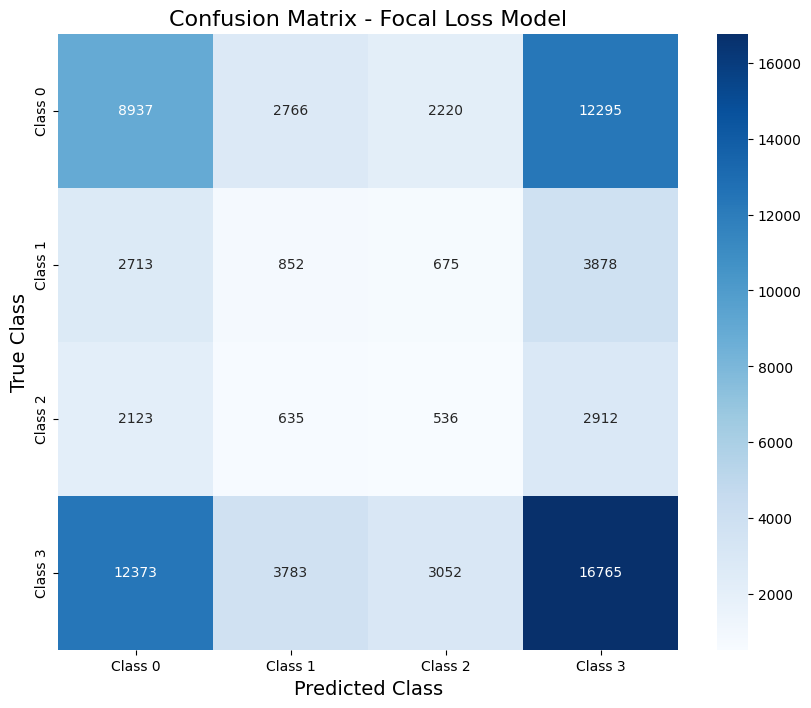

In [31]:
#Confusion Matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Get true labels from the validation set
# (Assuming your validation set is named 'validation_set_one_hot')
val_labels = np.concatenate([np.argmax(y.numpy(), axis=-1) for x, y in validation_set_one_hot], axis=0)

# 2. Get model predictions
print("Generating predictions...")
predictions = model.predict(validation_set_one_hot)
pred_labels = np.argmax(predictions, axis=-1)

# 3. Compute Confusion Matrix
cm = confusion_matrix(val_labels, pred_labels)

# 4. Plot
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'],
            yticklabels=['Class 0', 'Class 1', 'Class 2', 'Class 3'])
plt.title('Confusion Matrix - Focal Loss Model', fontsize=16)
plt.ylabel('True Class', fontsize=14)
plt.xlabel('Predicted Class', fontsize=14)

# ---> SAVE DIRECTLY TO DRIVE <---
# Ensure the folder exists first
import os
save_dir = '/content/drive/MyDrive/Eye_Disease_Project'
os.makedirs(save_dir, exist_ok=True)

save_path_cm = os.path.join(save_dir, 'confusion_matrix_focal_loss.png')
plt.savefig(save_path_cm, dpi=300, bbox_inches='tight')
print(f"Confusion Matrix saved to: {save_path_cm}")

plt.show()

Loss and F1 Graph saved to: /content/drive/MyDrive/Eye_Disease_Project/loss_f1_graph_focal_loss.png


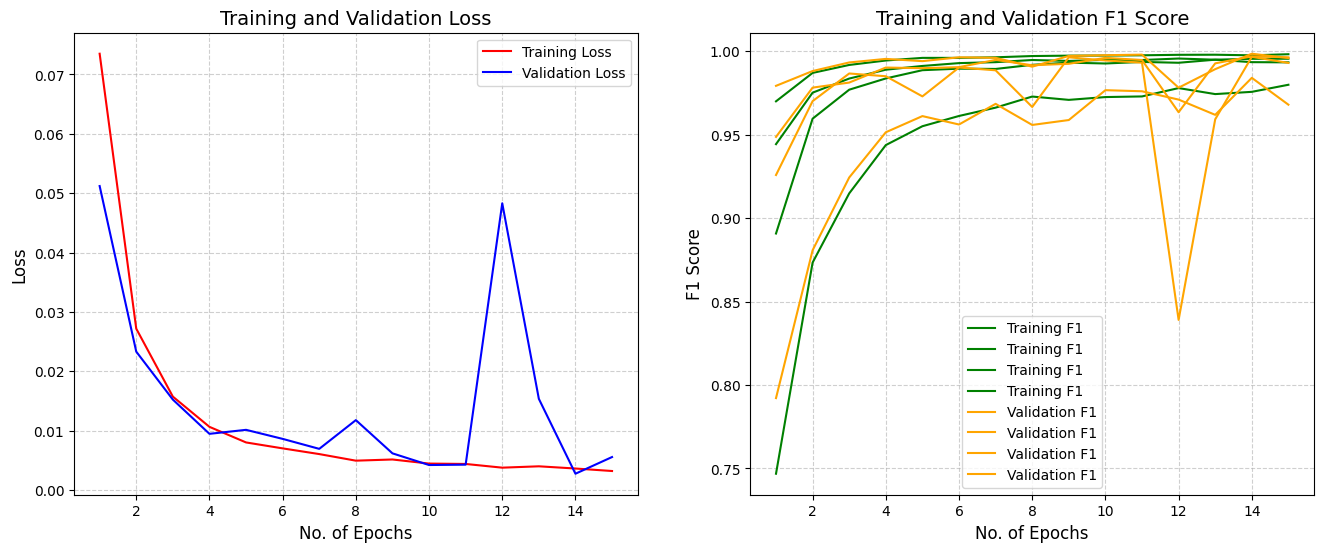

In [32]:
#Loss function visualization
import matplotlib.pyplot as plt
import os

# Check if you are using the variable from memory (training_history)
# or the loaded pickle file (load_history). Change this if needed:
history = training_history.history
# history = load_history  # <--- Uncomment this if you are using the loaded pickle

# Extract data
epochs = range(1, len(history['loss']) + 1)
train_loss = history['loss']
val_loss = history['val_loss']
train_f1 = history['f1_score']
val_f1 = history['val_f1_score']

# Create a figure with two subplots (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# --- Plot 1: Loss ---
ax1.plot(epochs, train_loss, color='red', label='Training Loss')
ax1.plot(epochs, val_loss, color='blue', label='Validation Loss')
ax1.set_xlabel("No. of Epochs", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.set_title("Training and Validation Loss", fontsize=14)
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.6)

# --- Plot 2: F1 Score ---
ax2.plot(epochs, train_f1, color='green', label='Training F1')
ax2.plot(epochs, val_f1, color='orange', label='Validation F1')
ax2.set_xlabel("No. of Epochs", fontsize=12)
ax2.set_ylabel("F1 Score", fontsize=12)
ax2.set_title("Training and Validation F1 Score", fontsize=14)
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.6)

# ---> SAVE DIRECTLY TO DRIVE <---
save_dir = '/content/drive/MyDrive/Eye_Disease_Project'
save_path_graph = os.path.join(save_dir, 'loss_f1_graph_focal_loss.png')

plt.savefig(save_path_graph, dpi=300, bbox_inches='tight')
print(f"Loss and F1 Graph saved to: {save_path_graph}")

plt.show()